## Peak performance comparison between Multi-core Scan and `torch.clone` copy operator

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["v", "^"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [2]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [128]

In [3]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [5]:
PREFIX_PATH = "../../../.."

df_baseline = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_baseline["S"] = "copy"
add_stats_siso(df_baseline, 2)


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.concat(map(pd.read_csv, glob(join(PREFIX_PATH, f"bench_results_mcscan*_{tile}_{dtype}.csv"))))
    df_tmp["S"] = df_tmp["operator"]
    df_tiled = pd.concat([df_tiled, df_tmp])

add_stats_siso(df_tiled, 4)

df = pd.concat([df_tiled])

## Paper plots

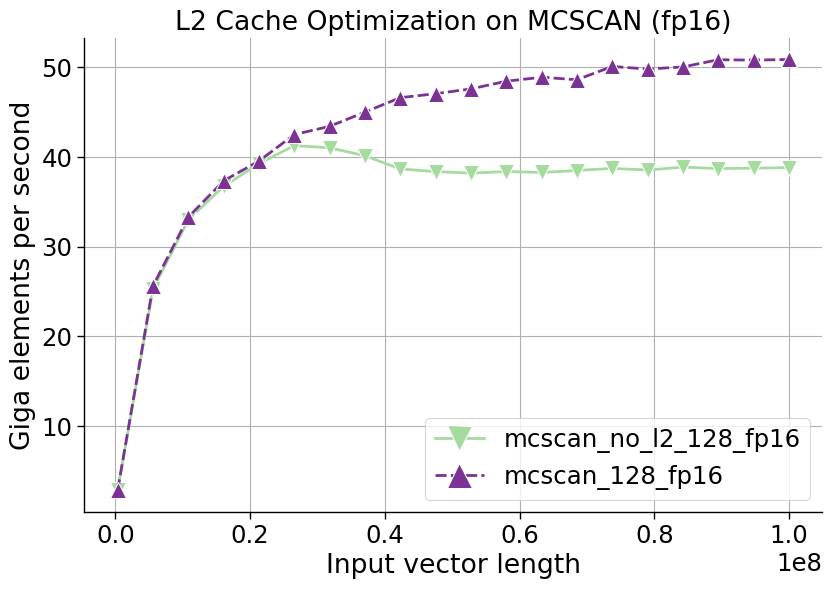

<Figure size 870x627 with 0 Axes>

In [7]:
palette = [### Colorbrewer colors
"#a6dba0",
"#7b3294"]

ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"L2 Cache Optimization on MCSCAN ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_l2_vs_no_l2_gelemsps_{dtype}.png")
plt.show()
plt.clf()

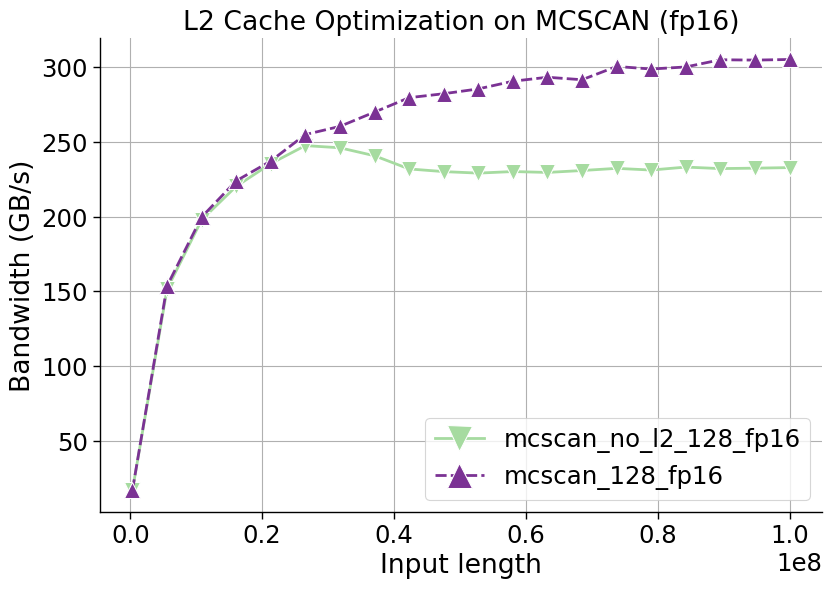

<Figure size 870x627 with 0 Axes>

In [9]:
palette = [### Colorbrewer colors
"#a6dba0",
"#7b3294"]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"L2 Cache Optimization on MCSCAN ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_l2_vs_no_l2_bw_{dtype}.png")
plt.show()
plt.clf()
